In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Country-data.csv')

In [3]:
df_model = df.drop('country', axis=1)

In [4]:
df_model

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_model = scaler.fit_transform(df_model)

In [6]:
from sklearn.cluster import KMeans

inertias = []

for i in range(1,10):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(df_model)
  inertias.append(kmeans.inertia_)
print(inertias)

[1503.0000000000002, 1050.2145582853307, 831.424435208687, 758.847102505072, 638.9440074189974, 550.4475856323835, 533.4016748019494, 493.8976538293449, 431.3939777418645]


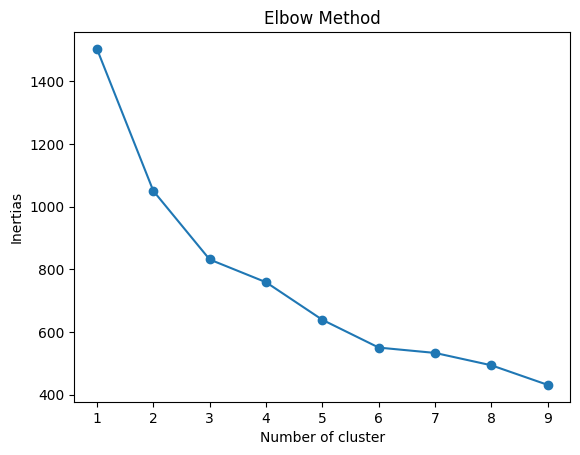

In [7]:
plt.plot(range(1,10), inertias, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of cluster')
plt.ylabel('Inertias')
plt.show()

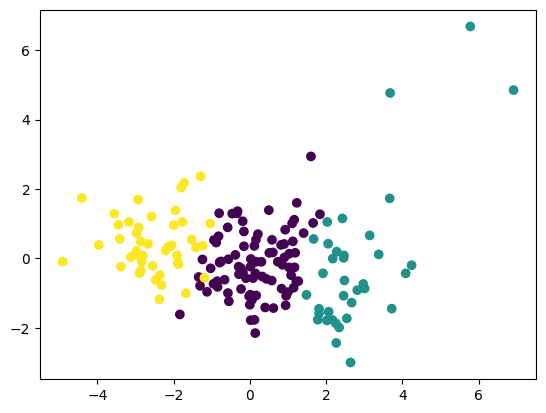

In [8]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_model)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_model)

plt.scatter(principal_components[:,0], principal_components[:,1],c = kmeans.labels_)
plt.show()

In [9]:
df = pd.DataFrame(df_model)
df['label'] = kmeans.labels_
df_display = pd.read_csv('/content/Country-data.csv')
df_display = pd.concat([df_display, df['label']], axis=1)
df_display

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,label
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2
